<a href="https://colab.research.google.com/github/LourdesBranchi/tp_final_especializacion/blob/main/03_analisis_resultados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Set up

In [ ]:
!git clone https://github.com/LourdesBranchi/tp_final_especializacion.git
%cd tp_final_especializacion
!pip install segmentation-models-pytorch SimpleITK -q

from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import pandas as pd
import torch
import SimpleITK as sitk
from scipy import stats
import matplotlib.pyplot as plt

from src.data_utils import cargar_metadata, particionar_pacientes
from src.preprocessing import resize_con_padding, normalizar_minmax
from src.models import crear_modelo
from src.metrics import dice_por_clase

Cloning into 'tp_final_especializacion'...
remote: Enumerating objects: 16, done.
remote: Counting objects: 100% (16/16), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 16 (delta 2), reused 13 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (16/16), 8.41 KiB | 8.41 MiB/s, done.
Resolving deltas: 100% (2/2), done.
/content/tp_final_especializacion
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 14.2 MB/s eta 0:00:00
Mounted at /content/drive


# Reproducimos la misma particion usada en el entrenamiento

In [ ]:
from google.colab import userdata

In [ ]:
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_API_TOKEN')

!kaggle datasets download -d shoybhasan/camus-human-heart-data
!unzip -q camus-human-heart-data.zip -d dataset_camus

import zipfile
with zipfile.ZipFile('dataset_camus/download', 'r') as zip_ref:
    zip_ref.extractall('datos_corazon')

Dataset URL: https://www.kaggle.com/datasets/shoybhasan/camus-human-heart-data
License(s): other
100% 3.50G/3.50G [00:40<00:00, 93.5MB/s]



In [ ]:
CARPETA_BASE = 'datos_corazon/database_nifti'
df_metadata = cargar_metadata(CARPETA_BASE)
particiones = particionar_pacientes(df_metadata, n_val_por_sexo=20, n_test_por_sexo=20, seed=42)
test_ids = particiones['test']

# Evaluación por paciente

In [ ]:
def evaluar_modelo_en_test(modelo, test_ids, df_metadata, carpeta_base, device):
    """Corre el modelo sobre cada imagen del test set y devuelve un DataFrame
    con Dice por estructura, por imagen, junto con el sexo del paciente."""
    modelo.eval()
    registros = []

    for pid in test_ids:
        sexo = df_metadata.loc[df_metadata.patient_id == pid, 'sex'].values[0]
        for vista in ['2CH', '4CH']:
            for fase in ['ED', 'ES']:
                img_path = os.path.join(carpeta_base, pid, f'{pid}_{vista}_{fase}.nii.gz')
                mask_path = os.path.join(carpeta_base, pid, f'{pid}_{vista}_{fase}_gt.nii.gz')
                if not (os.path.exists(img_path) and os.path.exists(mask_path)):
                    continue

                img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).astype(np.float32)
                mask = sitk.GetArrayFromImage(sitk.ReadImage(mask_path)).astype(np.int64)
                img = normalizar_minmax(resize_con_padding(img, 256, es_mascara=False))
                mask = resize_con_padding(mask, 256, es_mascara=True)

                img_t = torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)
                mask_t = torch.from_numpy(mask).long().to(device)

                with torch.no_grad():
                    pred = modelo(img_t).argmax(dim=1).squeeze(0)

                dices = dice_por_clase(pred, mask_t, num_clases=4)
                registros.append({
                    'patient_id': pid, 'sex': sexo, 'vista': vista, 'fase': fase,
                    'dice_LV': dices[1], 'dice_MYO': dices[2], 'dice_LA': dices[3],
                })

    return pd.DataFrame(registros)

# Cargar cada checkpoint y evaluar

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
DRIVE_DIR = '/content/drive/MyDrive/tesis_camus'

corridas = {
    'unet_imbalanced':     ('unet_resnet34', 'unet_resnet34_train_imbalanced_mejor.pt'),
    'resdunet_imbalanced': ('resdunet', 'resdunet_train_imbalanced_mejor.pt'),  # nombre corregido
    'ganador_balanced': ('unet_resnet34', 'unet_resnet34_train_balanced_mejor.pt'),  # ajustar según cuál ganó
}

resultados = {}
modelos = {}  # <- nuevo: guardamos el modelo cargado de cada corrida, no solo sus métricas
for nombre, (arq, archivo) in corridas.items():
    modelo = crear_modelo(arq, num_clases=4).to(device)
    modelo.load_state_dict(torch.load(os.path.join(DRIVE_DIR, archivo), map_location=device))
    modelo.eval()
    modelos[nombre] = modelo
    df_eval = evaluar_modelo_en_test(modelo, test_ids, df_metadata, CARPETA_BASE, device)
    resultados[nombre] = df_eval
    print(f"{nombre}: Dice LV medio = {df_eval['dice_LV'].mean():.4f}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

unet_imbalanced: Dice LV medio = 0.9279
resdunet_imbalanced: Dice LV medio = 0.9358
ganador_balanced: Dice LV medio = 0.9267


# Cargar curvas de entrenamiento

In [ ]:
# --- Curvas de aprendizaje: comparamos convergencia entre corridas ---
import json

historiales = {}
for nombre, (arquitectura, archivo_ckpt) in corridas.items():
    archivo_hist = archivo_ckpt.replace('_mejor.pt', '_historial.json')
    with open(os.path.join(DRIVE_DIR, archivo_hist)) as f:
        data = json.load(f)
    historiales[nombre] = data['historial']  # {'train_loss', 'val_loss', 'val_dice'}

# Comparacion curvas de aprendizaje

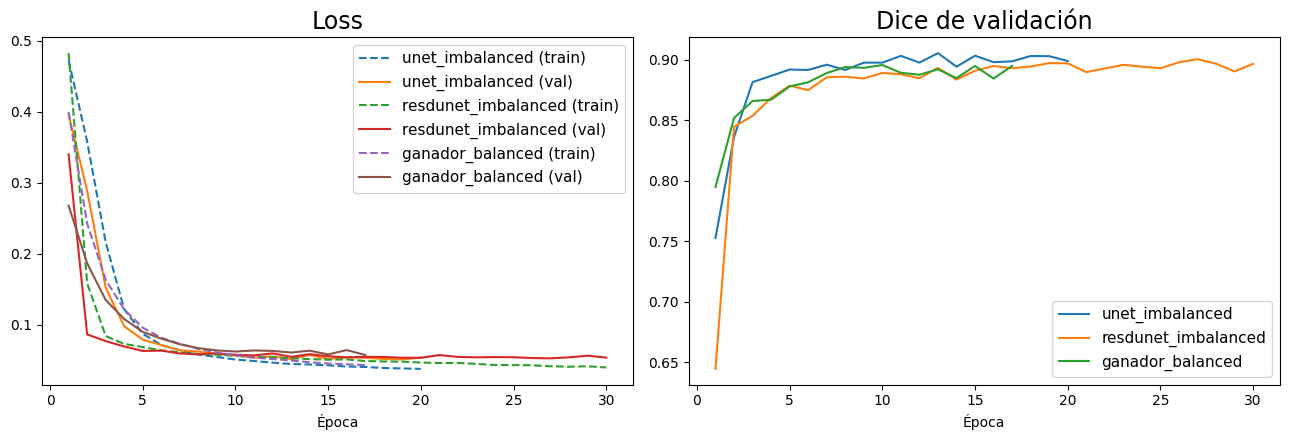

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for nombre, hist in historiales.items():
    epocas = range(1, len(hist['val_dice']) + 1)
    axes[0].plot(epocas, hist['train_loss'], '--', label=f'{nombre} (train)')
    axes[0].plot(epocas, hist['val_loss'], label=f'{nombre} (val)')
    axes[1].plot(epocas, hist['val_dice'], label=nombre)

axes[0].set_title('Loss', fontsize=17); axes[0].set_xlabel('Época'); axes[0].legend(fontsize=11)
axes[1].set_title('Dice de validación', fontsize=17); axes[1].set_xlabel('Época'); axes[1].legend(fontsize=11)
plt.tight_layout()
plt.show()
# Con esto se ve de un vistazo si ResDUnet converge más lento que unet_resnet34
# (esperable, al no tener encoder preentrenado -- ver Raghu et al. 2019)

# Comparacion Dice por sexo, por corrida

In [ ]:
import seaborn as sns

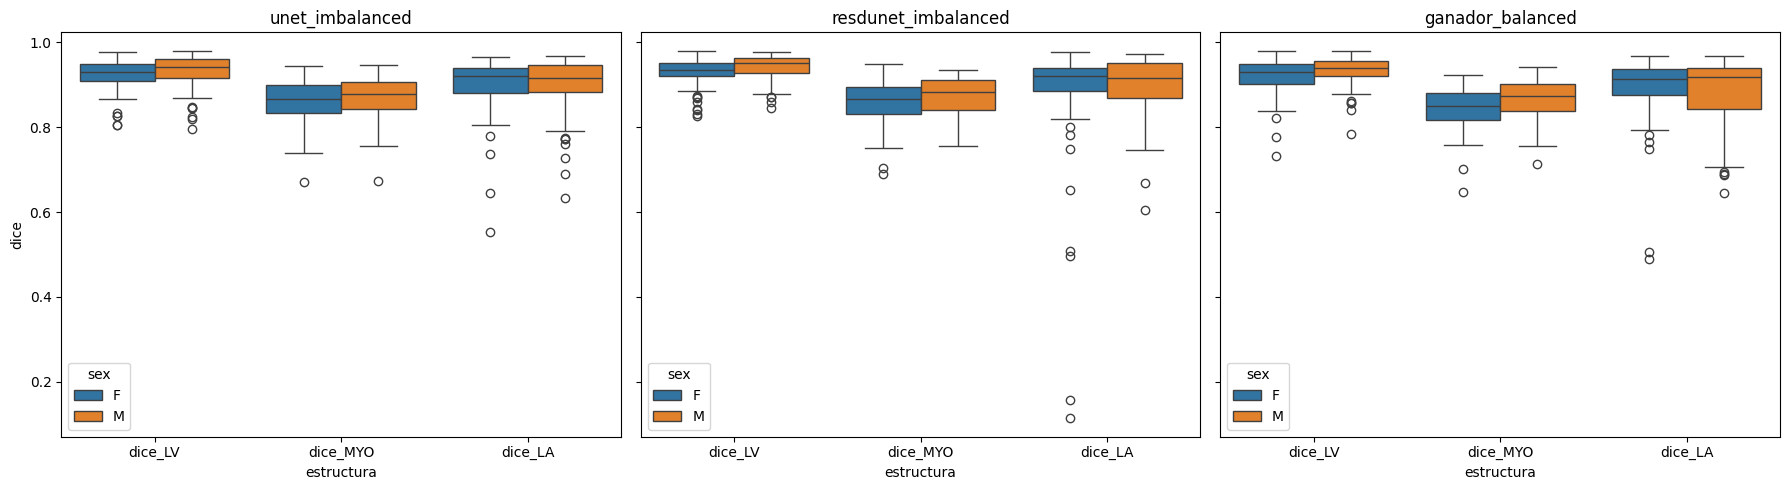

In [ ]:
n_corridas = len(resultados)
fig, axes = plt.subplots(1, n_corridas, figsize=(6 * n_corridas, 5), sharey=True)

# Si hay una sola corrida, axes no es un array — lo normalizamos para que el loop funcione igual
if n_corridas == 1:
    axes = [axes]

for ax, (nombre, df_eval) in zip(axes, resultados.items()):
    df_long = df_eval.melt(id_vars=['sex'], value_vars=['dice_LV', 'dice_MYO', 'dice_LA'],
                             var_name='estructura', value_name='dice')
    sns.boxplot(data=df_long, x='estructura', y='dice', hue='sex', ax=ax)
    ax.set_title(nombre)

plt.tight_layout()
plt.show()

# Test estadístico por corrida y estructura

In [ ]:
for nombre, df_eval in resultados.items():
    print(f"\n--- {nombre} ---")
    for estructura in ['dice_LV', 'dice_MYO', 'dice_LA']:
        f = df_eval[df_eval.sex == 'F'][estructura]
        m = df_eval[df_eval.sex == 'M'][estructura]
        u, p = stats.mannwhitneyu(f, m)
        print(f"{estructura}: F_mean={f.mean():.4f} M_mean={m.mean():.4f} p={p:.4f}")


--- unet_imbalanced ---
dice_LV: F_mean=0.9242 M_mean=0.9315 p=0.0666
dice_MYO: F_mean=0.8635 M_mean=0.8704 p=0.2123
dice_LA: F_mean=0.9008 M_mean=0.8994 p=0.8955

--- resdunet_imbalanced ---
dice_LV: F_mean=0.9292 M_mean=0.9424 p=0.0030
dice_MYO: F_mean=0.8592 M_mean=0.8743 p=0.0425
dice_LA: F_mean=0.8791 M_mean=0.9017 p=0.7705

--- ganador_balanced ---
dice_LV: F_mean=0.9199 M_mean=0.9335 p=0.0283
dice_MYO: F_mean=0.8427 M_mean=0.8649 p=0.0038
dice_LA: F_mean=0.8929 M_mean=0.8825 p=0.8685


# Tabla resumen

In [ ]:
# No alcanza con mirar el Dice general más alto: el objetivo de la tesis es medir
# sesgo, así que también miramos la brecha F-M. Una arquitectura puede tener mejor
# Dice promedio pero mayor brecha -- eso la haría "peor" para este trabajo puntual.

filas = []
for nombre, df_eval in resultados.items():
    fila = {'corrida': nombre}
    for estructura in ['dice_LV', 'dice_MYO', 'dice_LA']:
        f_mean = df_eval[df_eval.sex == 'F'][estructura].mean()
        m_mean = df_eval[df_eval.sex == 'M'][estructura].mean()
        fila[f'{estructura}_F'] = round(f_mean, 4)
        fila[f'{estructura}_M'] = round(m_mean, 4)
        fila[f'{estructura}_gap'] = round(m_mean - f_mean, 4)  # positivo = peor en mujeres
    filas.append(fila)

tabla_resumen = pd.DataFrame(filas)
tabla_resumen

,corrida,dice_LV_F,dice_LV_M,dice_LV_gap,dice_MYO_F,dice_MYO_M,dice_MYO_gap,dice_LA_F,dice_LA_M,dice_LA_gap
0,unet_imbalanced,0.9242,0.9315,0.0073,0.8635,0.8704,0.0070,0.9008,0.8994,-0.0014
1,resdunet_imbalanced,0.9292,0.9424,0.0132,0.8592,0.8743,0.0151,0.8791,0.9017,0.0226
2,ganador_balanced,0.9199,0.9335,0.0135,0.8427,0.8649,0.0222,0.8929,0.8825,-0.0104


# Bootstrap

In [ ]:
def bootstrap_ci(df_eval, estructura, sexo, n_iteraciones=2000, seed=42):
    """IC 95% del Dice promedio por bootstrap, remuestreando PACIENTES con reposición
    (no filas sueltas -- las 4 imágenes de un mismo paciente están correlacionadas)."""
    rng = np.random.default_rng(seed)
    pacientes = df_eval[df_eval.sex == sexo]['patient_id'].unique()
    medias = []
    for _ in range(n_iteraciones):
        muestra = rng.choice(pacientes, size=len(pacientes), replace=True)
        sub = df_eval[df_eval.patient_id.isin(muestra)]
        medias.append(sub[estructura].mean())
    return np.mean(medias), np.percentile(medias, 2.5), np.percentile(medias, 97.5)

filas_ci = []
for nombre, df_eval in resultados.items():
    for estructura in ['dice_LV', 'dice_MYO', 'dice_LA']:
        for sexo in ['F', 'M']:
            media, ci_low, ci_high = bootstrap_ci(df_eval, estructura, sexo)
            filas_ci.append({'corrida': nombre, 'estructura': estructura, 'sexo': sexo,
                              'media': round(media, 4), 'ci_95_low': round(ci_low, 4),
                              'ci_95_high': round(ci_high, 4)})

tabla_bootstrap = pd.DataFrame(filas_ci)
tabla_bootstrap

,corrida,estructura,sexo,media,ci_95_low,ci_95_high
0,unet_imbalanced,dice_LV,F,0.9242,0.9167,0.9325
1,unet_imbalanced,dice_LV,M,0.9315,0.9244,0.9381
2,unet_imbalanced,dice_MYO,F,0.8638,0.8527,0.8752
3,unet_imbalanced,dice_MYO,M,0.8702,0.8593,0.8811
4,unet_imbalanced,dice_LA,F,0.9011,0.8880,0.9141
5,unet_imbalanced,dice_LA,M,0.8993,0.8875,0.9113
6,resdunet_imbalanced,dice_LV,F,0.9292,0.9235,0.9354
7,resdunet_imbalanced,dice_LV,M,0.9425,0.9367,0.9483
8,resdunet_imbalanced,dice_MYO,F,0.8595,0.8495,0.8701
9,resdunet_imbalanced,dice_MYO,M,0.8742,0.8632,0.8851


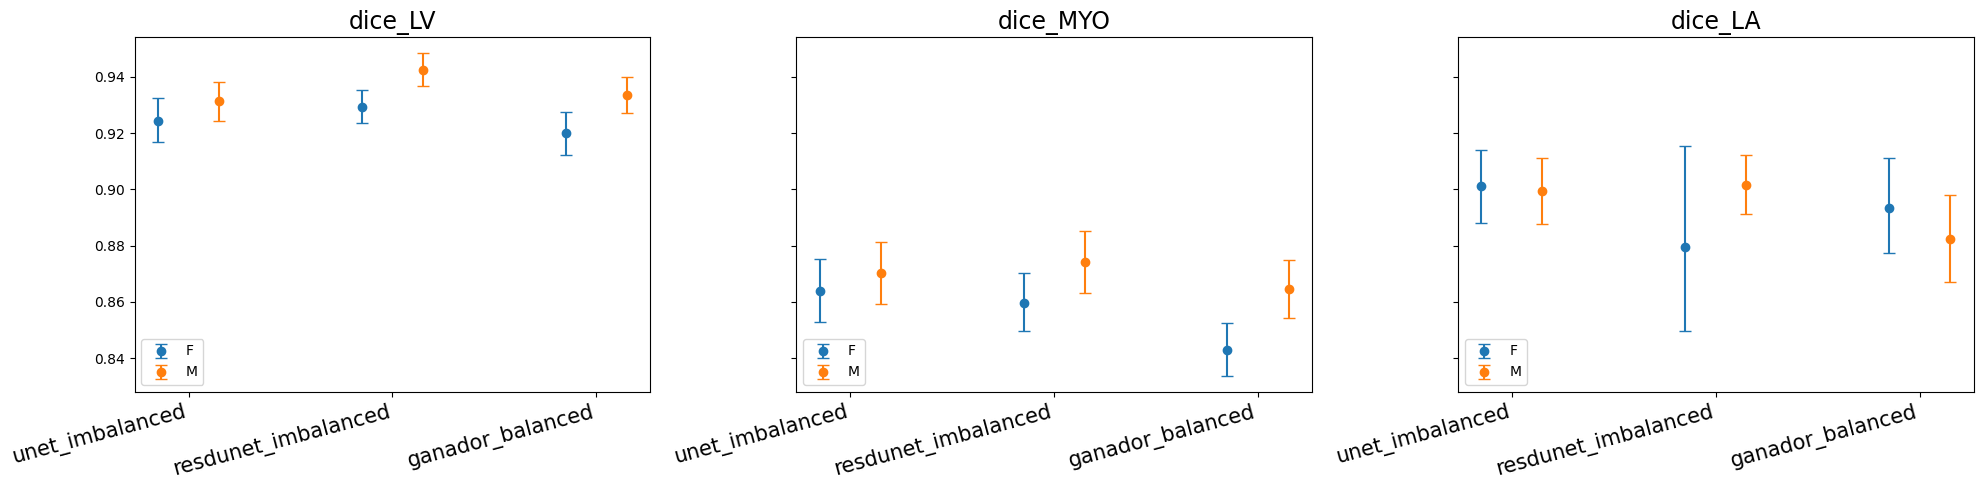

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)
estructuras = ['dice_LV', 'dice_MYO', 'dice_LA']
colores = {'F': 'tab:blue', 'M': 'tab:orange'}
offset = {'F': -0.15, 'M': 0.15}  # separa los puntos F/M para que no se pisen

for ax, estructura in zip(axes, estructuras):
    sub = tabla_bootstrap[tabla_bootstrap.estructura == estructura]
    corridas_unicas = sub['corrida'].unique()
    for i, corrida in enumerate(corridas_unicas):
        for sexo in ['F', 'M']:
            fila = sub[(sub.corrida == corrida) & (sub.sexo == sexo)].iloc[0]
            yerr = [[fila['media'] - fila['ci_95_low']], [fila['ci_95_high'] - fila['media']]]
            ax.errorbar(i + offset[sexo], fila['media'], yerr=yerr, fmt='o', color=colores[sexo],
                        capsize=4, label=sexo if i == 0 else None)
    ax.set_xticks(range(len(corridas_unicas)))
    ax.set_xticklabels(corridas_unicas, rotation=15, ha='right',  fontsize=15)
    ax.set_title(estructura,  fontsize=17)
    ax.legend(loc = 'lower left')

plt.tight_layout()
plt.show()
# Si el punto+barra de F y el de M NO se tocan verticalmente en una corrida,
# ahí hay evidencia sólida de disparidad para esa estructura.

# Seg-Grad-CAM sobre un caso de cada sexo

In [ ]:
resultados.keys()

dict_keys(['unet_imbalanced', 'resdunet_imbalanced', 'ganador_balanced'])

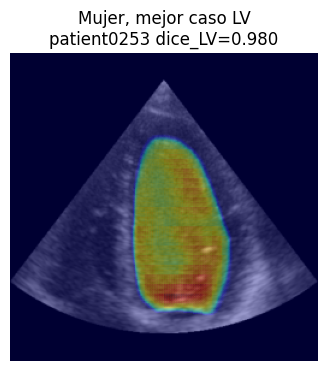

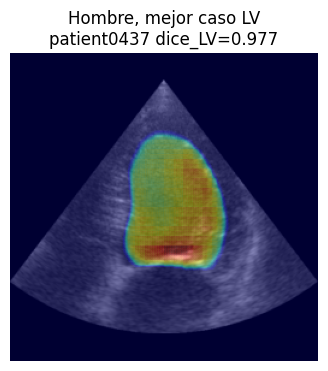

In [ ]:
from src.xai_utils import seg_grad_cam

# Casos elegidos a propósito: peor caso de LV en mujeres vs mejor caso en hombres,
# dentro de la corrida donde SÍ encontramos brecha sólida (resdunet_imbalanced)
df_resdunet = resultados['resdunet_imbalanced']
caso_f_mejor = df_resdunet[df_resdunet.sex == 'F'].nlargest(1, 'dice_LV').iloc[0]
caso_m_mejor = df_resdunet[df_resdunet.sex == 'M'].nlargest(1, 'dice_LV').iloc[0]

def cargar_imagen_test(patient_id, vista, fase, carpeta_base, device):
    """Mismo preprocesamiento que evaluar_modelo_en_test, para que el heatmap
    corresponda exactamente a lo que 've' el modelo."""
    img_path = os.path.join(carpeta_base, patient_id, f'{patient_id}_{vista}_{fase}.nii.gz')
    img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).astype(np.float32)
    img = normalizar_minmax(resize_con_padding(img, 256, es_mascara=False))
    return torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)

def mostrar_heatmap(modelo, caso, capa_conv, carpeta_base, device, titulo):
    img_t = cargar_imagen_test(caso['patient_id'], caso['vista'], caso['fase'], carpeta_base, device)
    heatmap = seg_grad_cam(modelo, img_t, clase_objetivo=1, capa_conv=capa_conv)  # 1 = LV

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img_t.squeeze().cpu(), cmap='gray')
    ax.imshow(heatmap, cmap='jet', alpha=0.4)
    ax.set_title(f"{titulo}\n{caso['patient_id']} dice_LV={caso['dice_LV']:.3f}")
    ax.axis('off')
    plt.show()

mostrar_heatmap(modelos['resdunet_imbalanced'], caso_f_mejor, modelos['resdunet_imbalanced'].dec1,
                 CARPETA_BASE, device, 'Mujer, mejor caso LV')
mostrar_heatmap(modelos['resdunet_imbalanced'], caso_m_mejor, modelos['resdunet_imbalanced'].dec1,
                 CARPETA_BASE, device, 'Hombre, mejor caso LV')

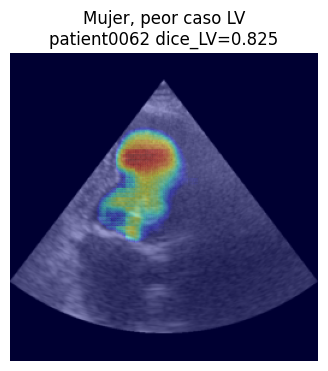

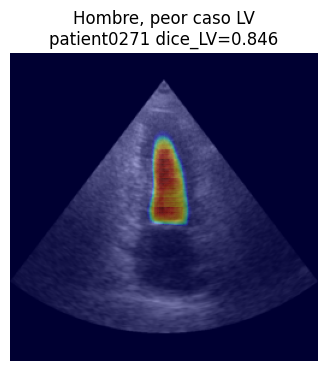

In [ ]:
from src.xai_utils import seg_grad_cam

# Casos elegidos a propósito: peor caso de LV en mujeres vs mejor caso en hombres,
# dentro de la corrida donde SÍ encontramos brecha sólida (resdunet_imbalanced)
caso_f_peor = df_resdunet[df_resdunet.sex == 'F'].nsmallest(1, 'dice_LV').iloc[0]
caso_m_peor = df_resdunet[df_resdunet.sex == 'M'].nsmallest(1, 'dice_LV').iloc[0]

def cargar_imagen_test(patient_id, vista, fase, carpeta_base, device):
    """Mismo preprocesamiento que evaluar_modelo_en_test, para que el heatmap
    corresponda exactamente a lo que 've' el modelo."""
    img_path = os.path.join(carpeta_base, patient_id, f'{patient_id}_{vista}_{fase}.nii.gz')
    img = sitk.GetArrayFromImage(sitk.ReadImage(img_path)).astype(np.float32)
    img = normalizar_minmax(resize_con_padding(img, 256, es_mascara=False))
    return torch.from_numpy(img).unsqueeze(0).unsqueeze(0).float().to(device)

def mostrar_heatmap(modelo, caso, capa_conv, carpeta_base, device, titulo):
    img_t = cargar_imagen_test(caso['patient_id'], caso['vista'], caso['fase'], carpeta_base, device)
    heatmap = seg_grad_cam(modelo, img_t, clase_objetivo=1, capa_conv=capa_conv)  # 1 = LV

    fig, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(img_t.squeeze().cpu(), cmap='gray')
    ax.imshow(heatmap, cmap='jet', alpha=0.4)
    ax.set_title(f"{titulo}\n{caso['patient_id']} dice_LV={caso['dice_LV']:.3f}")
    ax.axis('off')
    plt.show()

mostrar_heatmap(modelos['resdunet_imbalanced'], caso_f_peor, modelos['resdunet_imbalanced'].dec1,
                 CARPETA_BASE, device, 'Mujer, peor caso LV')
mostrar_heatmap(modelos['resdunet_imbalanced'], caso_m_peor, modelos['resdunet_imbalanced'].dec1,
                 CARPETA_BASE, device, 'Hombre, peor caso LV')

# Imagenes para informe

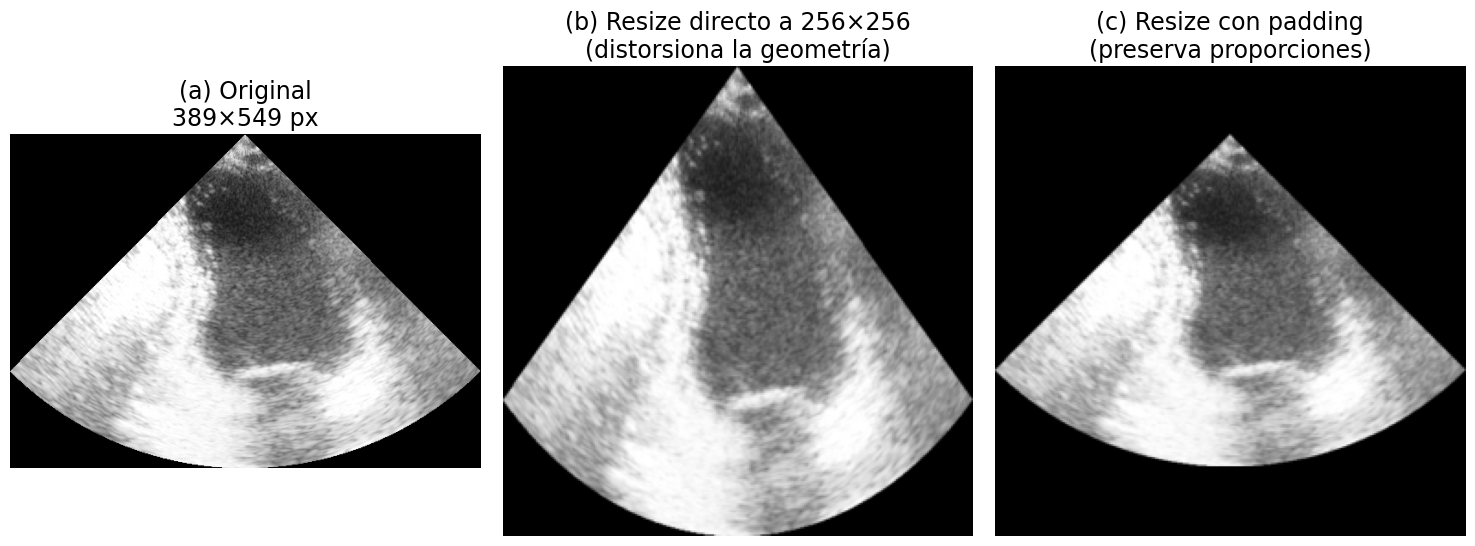

In [ ]:
# Pegar en una celda de Colab. Asume que ya clonaste tp_final_especializacion
# (para poder hacer `from src.preprocessing import resize_con_padding`) y que
# el dataset CAMUS ya está descargado en datos_corazon/database_nifti.

import numpy as np
import SimpleITK as sitk
from PIL import Image
import matplotlib.pyplot as plt

from src.preprocessing import resize_con_padding

plt.rcParams.update({"font.size": 15})

# --- elegí una imagen de ejemplo (cambiá la ruta si querés otro paciente) ---
ruta_img = "datos_corazon/database_nifti/patient0001/patient0001_2CH_ED.nii.gz"

arr = sitk.GetArrayFromImage(sitk.ReadImage(ruta_img)).astype(np.float32)
alto, ancho = arr.shape

# (a) original
img_original = arr

# (b) resize directo a 256x256 (distorsiona)
img_directo = np.array(Image.fromarray(arr).resize((256, 256), Image.BILINEAR))

# (c) resize con padding (tu función real del repo, preserva proporciones)
img_padding = resize_con_padding(arr, size=256, es_mascara=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))

axes[0].imshow(img_original, cmap="gray")
axes[0].set_title(f"(a) Original\n{alto}×{ancho} px", fontsize=17)
axes[0].axis("off")

axes[1].imshow(img_directo, cmap="gray")
axes[1].set_title("(b) Resize directo a 256×256\n(distorsiona la geometría)", fontsize=17)
axes[1].axis("off")

axes[2].imshow(img_padding, cmap="gray")
axes[2].set_title("(c) Resize con padding\n(preserva proporciones)", fontsize=17)
axes[2].axis("off")

plt.tight_layout()
plt.savefig("figura_3_3_resize_comparacion.png", dpi=200, bbox_inches="tight")
plt.show()

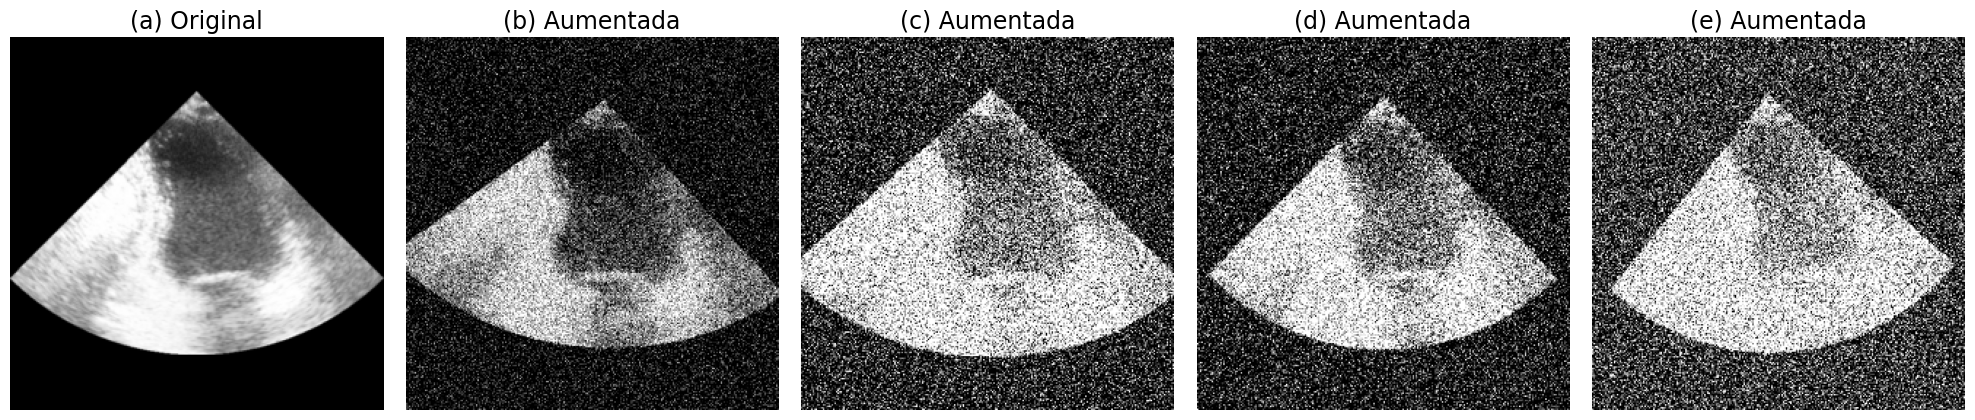

In [ ]:
# Pegar en una celda de Colab, después de la celda de la figura 3.3
# (reutiliza img_padding ya calculada ahí). Requiere albumentations:
# !pip install albumentations -q

import numpy as np
import albumentations as A
import matplotlib.pyplot as plt

from src.preprocessing import normalizar_minmax

plt.rcParams.update({"font.size": 15})

# Mismas transformaciones documentadas en la sección 3.1.4 de la memoria
transform = A.Compose([
    A.Affine(rotate=(-10, 10), scale=(0.9, 1.1), p=1.0),
    A.RandomBrightnessContrast(p=1.0),
    A.GaussNoise(p=1.0),
])

# --- IMPORTANTE: Albumentations asume que un array float ya está en [0,1]
# y clampea todo lo que supere ese rango a blanco. img_padding viene en
# escala 0-255 (sin normalizar), así que hay que pasarlo a uint8 antes,
# que es el formato que espera para trabajar con la escala 0-255 real. ---
img_base = (normalizar_minmax(img_padding) * 255).astype(np.uint8)

variantes = [transform(image=img_base)["image"] for _ in range(4)]

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

axes[0].imshow(img_base, cmap="gray", vmin=0, vmax=255)
axes[0].set_title("(a) Original", fontsize=17)
axes[0].axis("off")

letras = ["b", "c", "d", "e"]
for ax, letra, img_aug in zip(axes[1:], letras, variantes):
    ax.imshow(img_aug, cmap="gray", vmin=0, vmax=255)
    ax.set_title(f"({letra}) Aumentada", fontsize=17)
    ax.axis("off")

plt.tight_layout()
plt.savefig("figura_3_4_aumento_datos.png", dpi=200, bbox_inches="tight")
plt.show()